### 0. Import packages

In [1]:
import logomaker
import glob as glob
import sys, os

os.path.dirname(sys.executable)

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

import sys, os, json, textwrap, itertools, requests
from pathlib import Path

from Bio.PDB import PDBParser, NeighborSearch, is_aa
from Bio.Data.IUPACData import protein_letters_3to1

import re
from typing import Optional          

from Bio.PDB import PDBParser, NeighborSearch
from scipy.spatial.distance import cdist

from collections import Counter
from itertools import combinations
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon


### 1. Exploration of structure-dervied peptides

In [2]:
def grab_hla(title: str) -> Optional[str]:   # <- use Optional[str] instead of str | None
    """
    Return the first HLA allele in *title* or None.
    Handles:  HLA-A*02:01,  HLA-A02:01,  HLA-A*0201,  HLA-A0201
    """
    patterns = [
        r'(HLA-[A-Z]\*\d{2}:\d{2})',   # HLA-A*02:01
        r'(HLA-[A-Z]\d{2}:\d{2})',     # HLA-A02:01
        r'([A-Z]\*\d{4})',         # HLA-A*0201
        r'(-[A-Z]\*\d{2}:\d{2})'  ,
        r'([A-Z]\d{2}\d{2})'  ,
        r'([A-Z]\*\d{2}:\d{2})' ,
        r'(-[A-Z]\d{1}:\d{2})'  ,
        r'(-[A-Z]\d{1})'   ,
        r'(-[A-Z]\d{2})'            # HLA-A0201
    ]
    for p in patterns:
        m = re.search(p, title, flags=re.IGNORECASE)
        if m:
            return m.group(1).upper()
    return None

# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

results_meta['hla_allele'] = results_meta['title'].apply(grab_hla)
results_meta['hla_allele'] = results_meta['hla_allele'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))
results_meta = results_meta.drop_duplicates(['pdb_id', 'epitope'])

In [5]:
# keep only one copy of each (pdb_id, epitope) pair
peptides_by_pdb = (
    results_meta[(results_meta['plddt'] > 0.7) & (results_meta['i_ptm'] > 0.6)]
    .loc[:, ['pdb_id', 'epitope']]
    .drop_duplicates()
    .groupby('pdb_id')['epitope']
    .apply(list)
)
pdb_ids = peptides_by_pdb.index.tolist()

AA = "ACDEFGHIKLMNPQRSTVWY"

def build_pwm(seqs, max_len=9):
    """
    Return a (L × 20) frequency matrix, padding shorter peptides
    with '-' and ignoring them in the counts.
    """
    if not seqs:
        return np.zeros((max_len, 20))
    L = max_len
    mat = np.zeros((L, 20))
    for s in seqs:
        for i, aa in enumerate(s):
            if i >= L: break
            j = AA.index(aa)
            mat[i, j] += 1
    # convert to prob’s (add pseudocount to avoid 0)
    mat += 1e-6
    mat /= mat.sum(axis=1, keepdims=True)
    return mat

# build a PWM per PDB
pwms = {pdb: build_pwm(peps) for pdb, peps in peptides_by_pdb.items()}

def pwm_distance(M1, M2, metric="js"):
    if metric == "js":       # Jensen–Shannon divergence averaged over positions
        return np.mean([jensenshannon(M1[i], M2[i]) for i in range(M1.shape[0])])
    elif metric == "l1":     # simple L1 difference
        return np.sum(np.abs(M1 - M2))
    elif metric == "euclid": # Euclidean distance averaged over positions
        return np.mean([np.linalg.norm(M1[i] - M2[i]) for i in range(M1.shape[0])])
    else:
        raise ValueError("metric must be 'js', 'l1' or 'euclid'")

def pwm_distance_matrix(metric="js"):
    n = len(pdb_ids)
    D = np.zeros((n, n))
    for i, j in combinations(range(n), 2):
        d = pwm_distance(pwms[pdb_ids[i]], pwms[pdb_ids[j]], metric)
        D[i, j] = D[j, i] = d
    return pd.DataFrame(D, index=pdb_ids, columns=pdb_ids)

pwm_js   = pwm_distance_matrix(metric="js")   # divergence    (0 == identical)
pwm_l1   = pwm_distance_matrix(metric="l1")   # absolute diff (0 == identical)
pwm_euclid = pwm_distance_matrix(metric="euclid")  # Euclidean

# -------------------------------------------------------------
# 1 .  Map every PDB to its HLA allele
# -------------------------------------------------------------
# results_meta must contain a column named 'hla_allele' (grab_hla() gave you that).
pdb2hla = (
    results_meta[['pdb_id', 'hla_allele']]
    .dropna()
    .drop_duplicates(subset='pdb_id')
    .set_index('pdb_id')['hla_allele']
)

# fallback label for structures where HLA wasn’t detected
pwm_euclid = pwm_euclid.loc[pdb2hla.index.intersection(pwm_euclid.index)]  # keep only mapped PDBs
pdb2hla = pdb2hla.reindex(pwm_euclid.index).fillna('UNK')

# -------------------------------------------------------------
# 2 .  Re-order the matrix by HLA group, then by PDB
# -------------------------------------------------------------
order = (
    pdb2hla
    .sort_values(kind='mergesort')  # stable: keeps original PDB order within HLA block
    .index
)

M = pwm_js.loc[order, order]            # reordered similarity matrix
hla_order = pdb2hla.loc[order]          # parallel HLA list


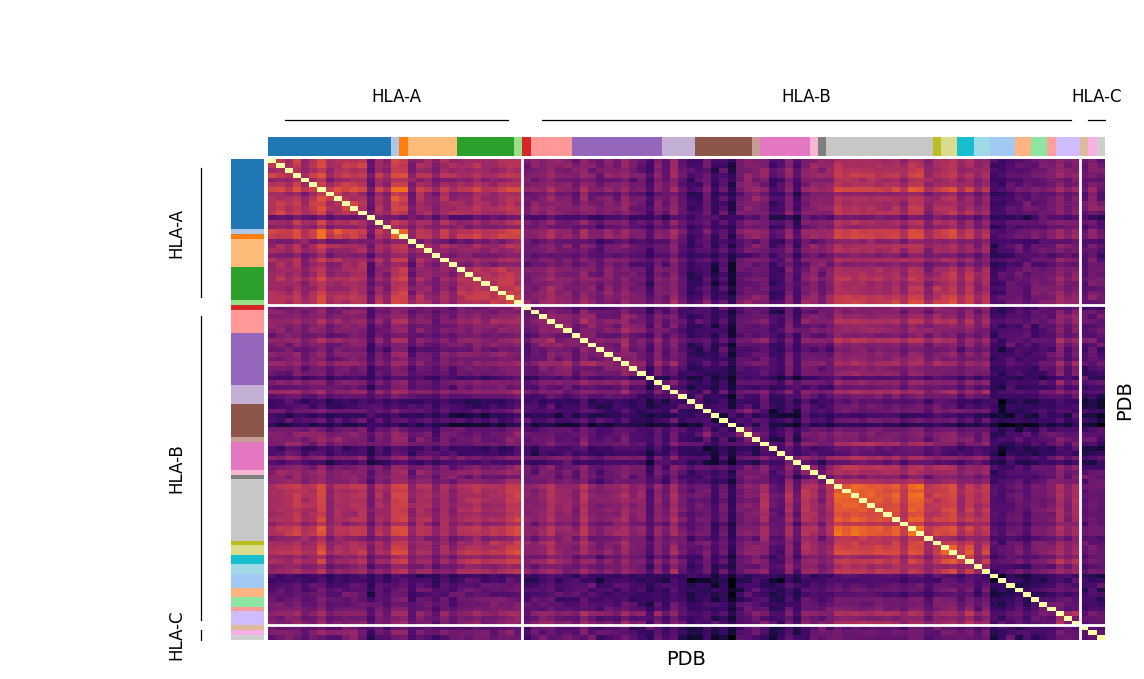

In [6]:
sorted_alleles = sorted(results_meta['hla_allele'].dropna().unique())

palette1 = sns.color_palette("tab20", 20)
palette2 = sns.color_palette("pastel", 10)
palette =   palette1 + palette2

# map colors to alleles
color_map = dict(zip(sorted_alleles, palette))
row_colors = hla_order.map(color_map)

# make the clustermap
g = sns.clustermap(
    M,
    cmap="inferno_r",
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    col_colors=row_colors,
    linewidths=0.0,
    figsize=(12, 9),
    cbar_pos=None
)

# disable all non-heatmap axes
for ax in [g.ax_row_colors, g.ax_col_colors, g.ax_row_dendrogram, g.ax_col_dendrogram]:
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xticklabels([]); ax.set_yticklabels([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.axis("off")

# heatmap labels
g.ax_heatmap.set_xlabel("PDB", fontsize=14)
g.ax_heatmap.set_ylabel("PDB", fontsize=14)
g.ax_heatmap.tick_params(axis="both", which="both", length=0, labelsize=10)
g.ax_heatmap.set_xticklabels([], rotation=90, ha="right", fontsize=5)
g.ax_heatmap.set_yticklabels([], rotation=0, fontsize=9)

# White divider lines and labels between HLA loci (A, B, C)
locus_order = hla_order.str[0]  # first character
locus_sizes = locus_order.value_counts(sort=False).loc[["A", "B", "C"]].values
cuts = np.cumsum(locus_sizes)

# Divider lines inside the heatmap
for cut in cuts[:-1]:
    g.ax_heatmap.axhline(cut, color="white", lw=2)
    g.ax_heatmap.axvline(cut, color="white", lw=2)

import re
# ----- clean, separated locus guides (A/B/C) -----
ax = g.ax_heatmap

# remove any inner dividers you added earlier
# (comment out any axhline/axvline drawn inside the heatmap)

# sizes per locus in current order
locus_order = hla_order.str[0]
sizes = (locus_order.value_counts(sort=False)
         .reindex(["A", "B", "C"])
         .fillna(0).astype(int))
assert sizes.sum() > 0, "No A/B/C loci found in hla_order."

tot = int(sizes.sum())
edges = np.cumsum([0] + sizes.tolist())
edges_prop = edges / tot                    # 0..1 along x (left→right)
centers_prop = 0.5*(edges_prop[:-1] + edges_prop[1:])
labels_top = ["HLA-A", "HLA-B", "HLA-C"]    # x labels (top)

# For the left side, rows are plotted top→bottom, but axes coords go bottom→top.
# Convert row block bounds to display coords so centering matches the visible blocks.
def row_bounds_display(i):
    y0 = 1.0 - edges_prop[i+1]   # top of block in display coords
    y1 = 1.0 - edges_prop[i]     # bottom of block in display coords
    return y0, y1
def row_center_display(i):
    y0, y1 = row_bounds_display(i)
    return 0.5*(y0 + y1)

# visual padding so lines do NOT touch color bars or the heatmap
pad_line_top   = 0.08   # distance above the top edge
pad_label_top  = 0.03   # distance between top line and text
pad_line_left  = 0.08   # distance left of the left edge
pad_label_left = 0.03   # distance between left line and text
gap = 0.02              # trim ends of segments so they never meet corners
lw  = 0.9               # thin guides

# draw guides + labels
for i in range(3):
    x0, x1 = edges_prop[i], edges_prop[i+1]
    # horizontal (top)
    ax.plot([x0+gap, x1-gap], [1.0 + pad_line_top, 1.0 + pad_line_top],
            transform=ax.transAxes, color="black", lw=lw,
            clip_on=False, zorder=6)
    ax.text(0.5*(x0+x1), 1.0 + pad_line_top + pad_label_top, labels_top[i],
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=12, fontweight="normal", color="black",
            clip_on=False, zorder=7)

    # vertical (left), using display-coord row bounds
    y0d, y1d = row_bounds_display(i)
    yc  = row_center_display(i)
    ax.plot([-pad_line_left, -pad_line_left], [y0d+gap, y1d-gap],
            transform=ax.transAxes, color="black", lw=lw,
            clip_on=False, zorder=6)
    ax.text(-pad_line_left - pad_label_left, yc, labels_top[i],
            transform=ax.transAxes, ha="center", va="center",
            rotation=90, fontsize=12, fontweight="normal",
            color="black", clip_on=False, zorder=7)

# leave your legend + spacing tweaks
g.fig.subplots_adjust(top=0.96, bottom=0.26)
plt.savefig('../figures/PWMS_HEATMAP.pdf')


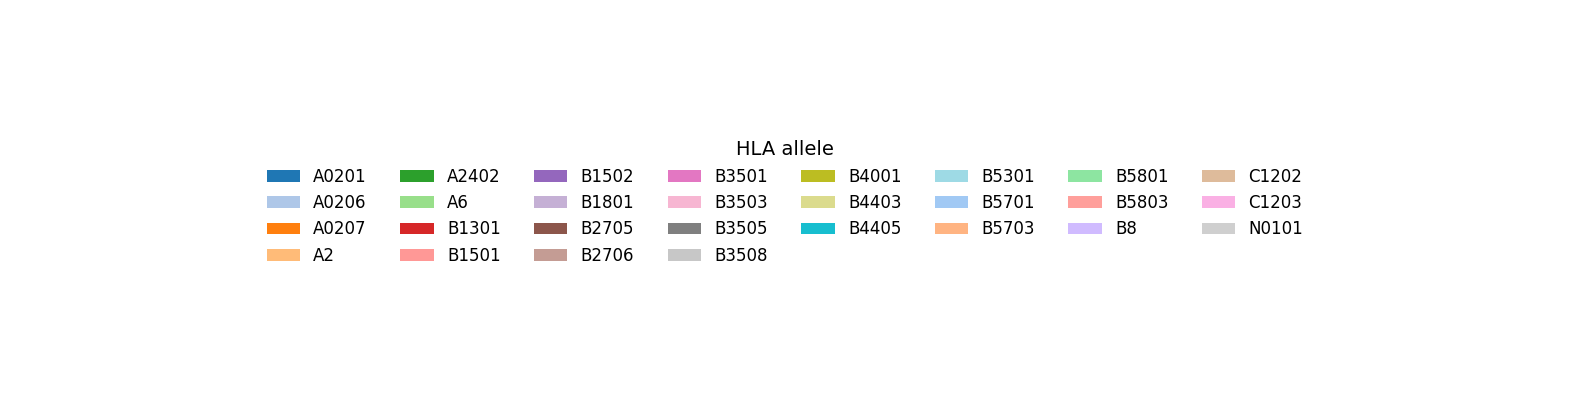

In [5]:
import matplotlib as mpl
from matplotlib.patches import Patch

# 2) LEGEND ONLY
legend_handles = [Patch(facecolor=color_map[h], label=h, linewidth=0) for h in sorted_alleles]
plt.figure(figsize=(20, 5))
plt.axis("off")
plt.legend(
    handles=legend_handles,
    loc="center",
    ncol=8,
    frameon=False,
    title="HLA allele",
    fontsize=12,
    title_fontsize=14
)

plt.savefig('../figures/PWMS_HEATMAP_LEGEND.pdf')
plt.show()

/tmp/ipykernel_3283592/1208459840.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("inferno_r")


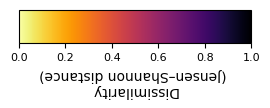

In [6]:
# Decide label/range from matrix
is_distance = np.allclose(np.diag(M.values), 0, atol=1e-9) and (M.values >= 0).all()

if is_distance:
    cbar_label = "Dissimilarity \n (Jensen–Shannon distance)"
    vmin, vmax = 0.0, 1.0  # JS distance ∈ [0, 1]
else:
    cbar_label = "Similarity score"
    vmin, vmax = float(M.values.min()), float(M.values.max())

# --- small stand-alone colorbar ---
fig, ax = plt.subplots(figsize=(3, 1))
fig.subplots_adjust(bottom=0.55)

cmap = mpl.cm.get_cmap("inferno_r")
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cbar = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')
cbar.ax.tick_params(labelsize=8)
cbar.set_label(cbar_label, fontsize=10, rotation = 180)
plt.savefig('../figures/PWMS_HEATMAP_COLORBAR.pdf', bbox_inches='tight')
plt.show()
